In [1]:
import pandas as pd

df = pd.read_csv('../datasets/redmi6.csv', encoding='windows-1252')

In [2]:
df.sample(10)

,Review Title,Customer name,Rating,Date,Category,Comments,Useful
212,res for custmer,Sachin Wadhawan,5.0 out of 5 stars,on 25 September 2018,Others,like,NaN
76,Fully satisfied,Mishra Food N Agro,5.0 out of 5 stars,on 22 September 2018,Others,One of the best..... In the price range,
259,Good for sharp use,Shankar,4.0 out of 5 stars,on 28 September 2018,Others,Dislike snapdragon 425,NaN
276,Mi is best phone,Sunil Soni,4.0 out of 5 stars,on 18 September 2018,Others,Product is avasome but invoice is note include...,NaN
167,Excellent,????? ?????,5.0 out of 5 stars,on 19 September 2018,Others,Excellent,NaN
227,UNBOXING AND CAMERA SHOTS!,TECHBORED! Himanshu Chatra,5.0 out of 5 stars,on 22 September 2018,Display,Hey guys this is TECHBORED! and this is unboxi...,
145,best phone in budget,mohammed imroz,5.0 out of 5 stars,on 28 September 2018,Others,awosome phone,NaN
221,Got a defective one and requested for a replac...,Anoopcbose,1.0 out of 5 stars,on 22 September 2018,Display,Phone is really nice and good looking.\nI thin...,
35,good phone,ANUPOM BHUNIYA,5.0 out of 5 stars,on 18 September 2018,Others,very good phone of this budget......red colour...,2 people found this helpful
49,Redmi Pro 6,Amazon Customer,3.0 out of 5 stars,on 25 September 2018,Battery,"Awesome sound quality , battery life is good ,...",One person found this helpful


In [3]:
df.isnull().sum()

# We don't use 'Useful' column, so no problem with missing values

Review Title       0
Customer name      0
Rating             0
Date               0
Category           0
Comments           0
Useful           170
dtype: int64

In [4]:
df['Rating'] = df['Rating'].str.split(' ', expand=True)[0]

In [5]:
df['Rating'].unique().tolist()

['4.0', '3.0', '5.0', '2.0', '1.0']

In [6]:
df.sample(10)

,Review Title,Customer name,Rating,Date,Category,Comments,Useful
249,average phone,sarfaraz alam,3.0,on 25 September 2018,Battery,after using two weeks i just analyse that it i...,
147,Very nice,Shiva,4.0,on 18 September 2018,Others,Mobile is very nice.,NaN
96,Very good desain,MAHAVIRSINH R JADEJA,3.0,on 29 September 2018,Others,Sound qulity not dolby and processor performan...,NaN
235,Don't buy this mobile mi 6 pro,Vasudevan,1.0,on 15 September 2018,Display,"Very poor quality in front facing camera, and ...",NaN
275,"Cemera quality,face unlock most important in t...",Rahul,5.0,on 19 September 2018,Others,"I like This Phone, Awesome look and design.\nI...",NaN
182,Good rear camera,Amazon Customer,3.0,on 23 September 2018,Others,Overall good,NaN
46,Good service,Manowar,4.0,on 17 September 2018,Delivery,Nice product. Delivery guy also.,2 people found this helpful
104,Product is good,Suman Bag,5.0,on 27 September 2018,Battery,"This product is very good, battery backup is v...",NaN
250,Bad experience ever battery% doesn't show.Low ...,Subbhajit jana,1.0,on 19 September 2018,Display,Bad experience ever battery% doesn't show.Low ...,NaN
230,A compact power pack Device with great battery...,kunal Sethi,5.0,on 20 September 2018,Display,This device feels great in hand because it is ...,NaN


In [7]:
df = df[['Rating', 'Comments', 'Category']]

In [8]:
# Check for missing values

df.isnull().sum()

Rating      0
Comments    0
Category    0
dtype: int64

In [9]:
df.sample(10)

,Rating,Comments,Category
61,3.0,"Good phone but not value for money, Prefer Red...",Others
156,5.0,It's awesome phone.,Others
42,4.0,Good,Others
95,5.0,Good mobile.. battery backup good,Battery
220,1.0,Please don't buy!!\n\nHorrible phone from Xiao...,Camera
263,4.0,Very good phone at this price. Display quality...,Display
151,5.0,Mind blowing,Others
200,5.0,Good,Others
211,5.0,Nice,Others
139,5.0,"Awesome mobile, value of money...",Others


In [10]:
df.count()

Rating      280
Comments    280
Category    280
dtype: int64

In [12]:
# This code is used to categorize comments into different sentiment categories using the Ollama API (with qwen2.5-coder:latest model).

from tqdm import tqdm
import ollama
import time

# Add a progress bar
for i in tqdm(range(len(df)), desc="Processing comments"):
    comment = df.loc[i, 'Comments']
    comment_category = 'Unknown'

    try:
        response = ollama.generate(
            model='qwen2.5-coder:latest',  
            prompt=f"Categorize the following comment into exactly one of these categories: Very Negative, Negative, Neutral, Positive, Very Positive. Comment: {comment}"
        )
        
        result = response['response'].strip()
        if result in ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']:
            comment_category = result
            
    except Exception as e:
        print(f"Error processing comment {i}: {str(e)}")
        
    df.loc[i, 'Comment Categories'] = comment_category
    
    # Add a small delay to avoid overwhelming the API
    time.sleep(0.1)

Processing comments: 100%|██████████| 280/280 [08:31<00:00,  1.83s/it]


In [13]:
df.isnull().sum()

Rating                0
Comments              0
Category              0
Comment Categories    0
dtype: int64

In [14]:
df['Comment Categories'].unique().tolist()

['Unknown',
 'Negative',
 'Positive',
 'Neutral',
 'Very Negative',
 'Very Positive']

In [15]:
# Only load data that Comment Category equals to 'Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive', avoid 'Unknown' 
df = df[df['Comment Categories'].isin(['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive'])]

In [16]:
df['Comment Categories'].unique().tolist()

['Negative', 'Positive', 'Neutral', 'Very Negative', 'Very Positive']

In [17]:
df.count()

Rating                250
Comments              250
Category              250
Comment Categories    250
dtype: int64

In [20]:
# Change data type
df.loc[:,'Rating'] = df['Rating'].astype(float)

In [21]:
# Do mapping Rating Categories
df.loc[:,'Rating Categories'] = df['Rating'].map({5.0: 'Very Positive', 4.0: 'Positive', 3.0: 'Neutral', 2.0: 'Negative', 1.0: 'Very Negative'}) 

In [22]:
df.sample(10)

,Rating,Comments,Category,Comment Categories,Rating Categories
35,5.0,very good phone of this budget......red colour...,Others,Positive,Very Positive
122,5.0,Hello,Others,Neutral,Very Positive
161,5.0,Superb????????????,Others,Very Positive,Very Positive
134,1.0,Bad facility for replacement,Others,Negative,Very Negative
198,5.0,Its osm,Others,Neutral,Very Positive
254,5.0,Bettary so good,Others,Positive,Very Positive
29,5.0,Good phone at such a valuable price. Notch dis...,Display,Positive,Very Positive
135,5.0,I've fallen in love!,Others,Very Positive,Very Positive
246,5.0,I loved the fact that Lenovo gave me such a ni...,Others,Positive,Very Positive
107,5.0,Best notch light weight phon.,Others,Positive,Very Positive


In [23]:
df.isnull().sum()

Rating                0
Comments              0
Category              0
Comment Categories    0
Rating Categories     0
dtype: int64

In [24]:
# Count occurrences of each category in both columns
rating_categories_counts = df['Rating Categories'].value_counts()
comment_categories_counts = df['Comment Categories'].value_counts()

# Find common categories
common_categories = rating_categories_counts.index.intersection(comment_categories_counts.index)

# Compare counts for common categories
comparison = pd.DataFrame({
    'Rating Categories Count': rating_categories_counts[common_categories],
    'Comment Categories Count': comment_categories_counts[common_categories]
})

print(comparison)

               Rating Categories Count  Comment Categories Count
Very Positive                      144                         3
Positive                            44                       162
Very Negative                       35                        15
Neutral                             19                        18
Negative                             8                        52


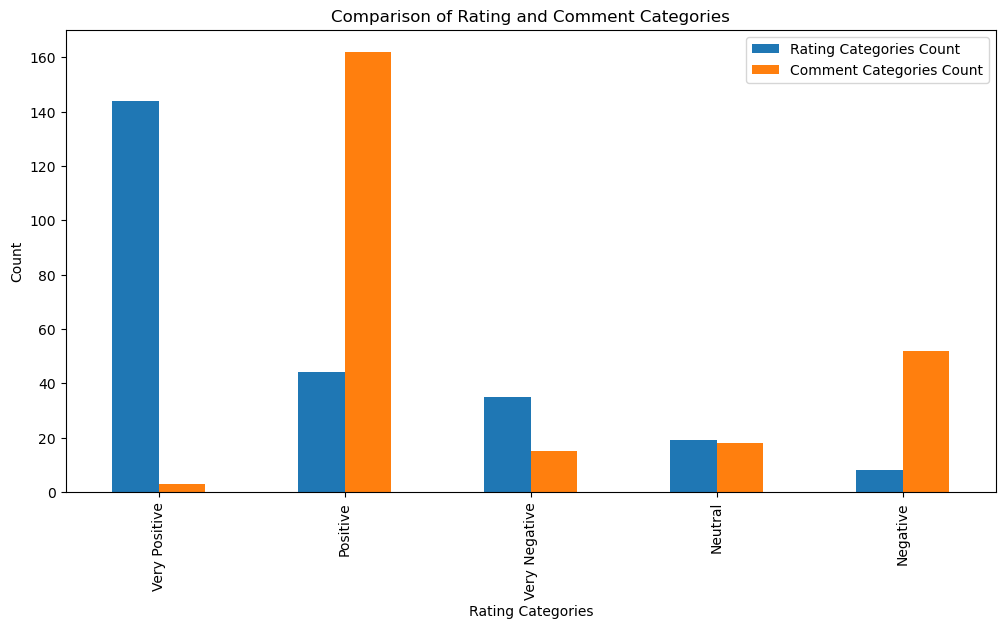

In [25]:
import matplotlib.pyplot as plt

# Create a bar plot to compare the counts of rating and comment categories
comparison.plot(kind='bar', figsize=(12, 6))

# Set labels and title
plt.xlabel('Rating Categories')
plt.ylabel('Count')
plt.title('Comparison of Rating and Comment Categories')

# Show the plot
plt.show()

In [26]:
# Get the mismatches
mismatches = df[df['Rating Categories'].str.lower() != df['Comment Categories'].str.lower()]

print(f"Mismatches found: {len(mismatches)}")

Mismatches found: 186


In [27]:
# Do mapping Rating Categories
df.loc[:,'Rating Categories'] = df['Rating Categories'].map({'Very Positive': 'Positive', 'Positive': 'Positive', 'Neutral': 'Neutral', 'Negative': 'Negative', 'Very Negative': 'Negative'}) 

In [28]:
# Do mapping Comment Categories
df.loc[:, 'Comment Categories'] = df['Comment Categories'].map({'Very Positive': 'Positive', 'Positive': 'Positive', 'Neutral': 'Neutral', 'Negative': 'Negative', 'Very Negative': 'Negative'})

In [29]:
df.isnull().sum()

Rating                0
Comments              0
Category              0
Comment Categories    0
Rating Categories     0
dtype: int64

In [30]:
# Count occurrences of each category in both columns
rating_categories_counts = df['Rating Categories'].value_counts()
comment_categories_counts = df['Comment Categories'].value_counts()

# Find common categories
common_categories = rating_categories_counts.index.intersection(comment_categories_counts.index)

# Compare counts for common categories
comparison = pd.DataFrame({
    'Rating Categories Count': rating_categories_counts[common_categories],
    'Comment Categories Count': comment_categories_counts[common_categories]
})

print(comparison)

          Rating Categories Count  Comment Categories Count
Positive                      188                       165
Negative                       43                        67
Neutral                        19                        18


In [31]:
# Get mismatches
mismatches = df[df['Rating Categories'].str.lower() != df['Comment Categories'].str.lower()]

print(f"Mismatches found: {len(mismatches)}")

Mismatches found: 45


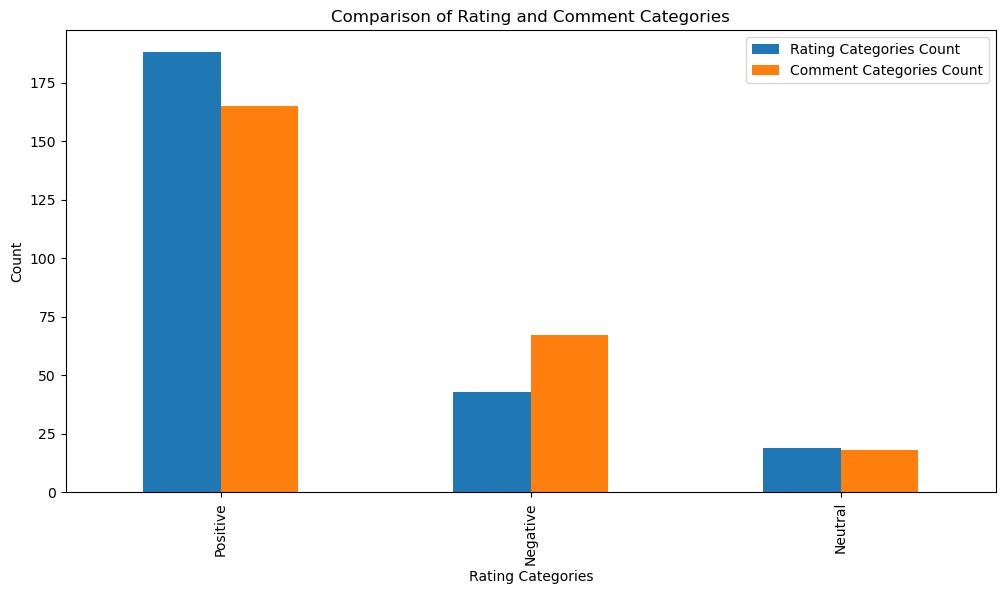

In [32]:
# Create a bar plot to compare the counts of rating and comment categories
comparison.plot(kind='bar', figsize=(12, 6))

# Set labels and title
plt.xlabel('Rating Categories')
plt.ylabel('Count')
plt.title('Comparison of Rating and Comment Categories')

# Show the plot
plt.show()

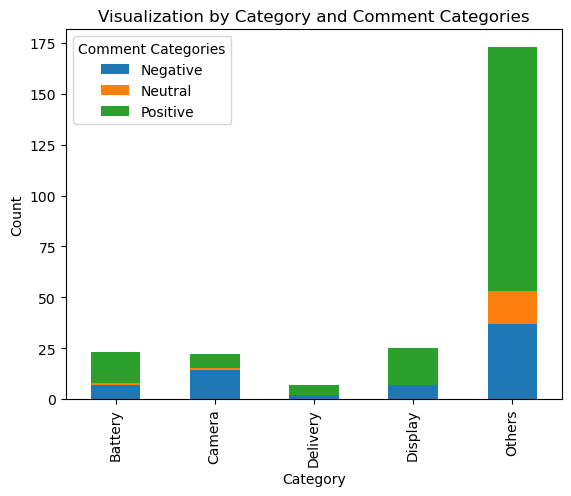

In [33]:
# Create pivot table
pivot_table = df.pivot_table(index='Category', columns='Comment Categories', aggfunc='size', fill_value=0)

# Display the pivot table
pivot_table.plot(kind='bar', stacked=True)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Visualization by Category and Comment Categories')
plt.show()